# Joint Agent-Count Sweep

Evaluate one selected approach with different physical UAV/UGV counts. HAPPO preserves the checkpoint observation schema while changing only physical agents; heuristic approaches reuse the checkpoint-derived scenario settings. The matrix shows confirmation AUC for each `[UAV, UGV]` combination; every cell is annotated as `mean +/- std`.

Set exactly one `APPROACH` (`happo`, `ant_colony`, `lawnmower`, and so on). When `FILELIST` is empty, the notebook runs the matching diagnostic for every configured combination, with up to `MAX_PARALLEL_RUNS` combinations running concurrently. When files are supplied, agent counts are read from each JSON (with the filename used only as a fallback), so file order cannot transpose the matrix.


In [1]:
APPROACH = 'happo'
MODLABEL = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 5
NSURVIVORS_MAX = 10

# Entries are [number of physical UAVs, number of physical UGVs].
# AGENT_COMBINATIONS = [
#     [2, 1], [2, 2], [2, 3],
#     [3, 1], [3, 2], [3, 3],
#     [4, 1], [4, 2], [4, 3],
# ]

AGENT_COMBINATIONS = [
    [2, 1], [2, 2], [2, 3],
    [3, 1], [3, 2], [3, 3],
    [4, 1], [4, 2], [4, 3],
]

TRAINED_COMBINATION = [4,3]

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
# Use 1 for sequential execution; increase carefully because each diagnostic is CPU intensive.
MAX_PARALLEL_RUNS = 1
EXTRA_DIAGNOSTIC_ARGS = []

# Existing agent-sweep JSON files for APPROACH. Leave empty to run missing combinations.
FILELIST = []
# FILELIST = [
#     'outputs/team_size_sweep/happo_uav2_ugv1_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav2_ugv2_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav2_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav3_ugv1_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav3_ugv2_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav3_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav4_ugv1_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav4_ugv2_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
#     'outputs/team_size_sweep/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_1000_1099.json',
# ]


In [2]:
import json
import re
import shlex
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


def _approach_tag(approach):
    if not isinstance(approach, str):
        raise TypeError('APPROACH must be one string, not a list of approaches')
    return str(approach).strip().lower().replace('-', '_')


APPROACH = _approach_tag(APPROACH)
if not APPROACH:
    raise ValueError('APPROACH must name exactly one diagnostic approach')
APPROACH_LABELS = {
    'happo': 'HAPPO',
    'ant_colony': 'ACO',
    'lawnmower': 'Lawnmower',
    'random_walk': 'Random Walk',
    'random_action': 'Random Action',
    'highest_confidence': 'Highest Confidence',
}
APPROACH_LABEL = APPROACH_LABELS.get(APPROACH, APPROACH.replace('_', ' ').title())
HAPPO_SCRIPT = Path('scripts/diagnose_joint_physical_ablation_happo.py')
BASELINE_SCRIPT = Path('scripts/diagnose_joint_baseline_strategies.py')
SCRIPT = HAPPO_SCRIPT if APPROACH == 'happo' else BASELINE_SCRIPT

CWD = Path.cwd().resolve()
if (CWD / SCRIPT).is_file():
    PROJECT_ROOT = CWD
elif (CWD.parent / SCRIPT).is_file():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(f'Could not locate {SCRIPT}')

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'team_size_sweep'


def _resolve_path(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


def _modlabel_for_agents(n_uavs, n_ugvs):
    varied_label, replacement_count = re.subn(
        r'(?<![A-Za-z0-9])uav\d+_ugv\d+(?![A-Za-z0-9])',
        f'uav{n_uavs}_ugv{n_ugvs}',
        MODLABEL,
        count=1,
        flags=re.IGNORECASE,
    )
    if replacement_count != 1:
        raise ValueError(
            'MODLABEL must contain one uav<number>_ugv<number> segment so the '
            'agent sweep can replace it safely'
        )
    return varied_label


def _output_paths(n_uavs, n_ugvs):
    stem = f'{APPROACH}_{_modlabel_for_agents(n_uavs, n_ugvs)}_seeds_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'


def _diagnostic_command(checkpoint, n_uavs, n_ugvs, seeds, json_output, plots_output):
    if APPROACH == 'happo':
        command = [
            sys.executable,
            str(PROJECT_ROOT / HAPPO_SCRIPT),
            '--checkpoint-dir', str(checkpoint),
        ]
    else:
        command = [
            sys.executable,
            str(PROJECT_ROOT / BASELINE_SCRIPT),
            '--strategy', APPROACH,
            '--happo-checkpoint', str(checkpoint),
        ]
    command.extend([
        '--n-uavs', str(n_uavs),
        '--n-ugvs', str(n_ugvs),
        '--steps', str(NSTEPS_PER_EPISODE),
        '--seeds', *seeds,
        '--n-survivors', str(NSURVIVORS_OBS),
        '--active-survivors-min', str(NSURVIVORS_MIN),
        '--active-survivors-max', str(NSURVIVORS_MAX),
        '--json-output', str(json_output),
        '--plots-output', str(plots_output),
    ])
    command.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
    return command


def _payload_scenario(payload):
    for candidate in (
        payload.get('scenario'),
        payload.get('scenario_kwargs'),
        payload.get('metadata', {}).get('scenario_kwargs'),
    ):
        if isinstance(candidate, dict) and candidate:
            return candidate
    return {}


def _agent_counts(path, payload):
    scenario = _payload_scenario(payload)
    n_uavs = scenario.get('n_drones')
    n_ugvs = scenario.get('n_ground')
    if n_uavs is not None and n_ugvs is not None:
        return int(n_uavs), int(n_ugvs)

    match = re.search(r'uav(\d+)_ugv(\d+)', path.stem, flags=re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    raise ValueError(f'Could not determine UAV/UGV counts from {path}')


def _diagnostic_approach(path, payload):
    metadata = payload.get('metadata', {})
    candidate = payload.get('strategy') or payload.get('approach')
    if candidate is None and isinstance(metadata, dict):
        candidate = metadata.get('strategy') or metadata.get('approach')
    if candidate is not None:
        return _approach_tag(candidate)
    stem = path.stem.lower()
    return next(
        (name for name in APPROACH_LABELS if stem.startswith(f'{name}_')),
        None,
    )


def _confirm_auc_stats(payload):
    summary = payload.get('summary', {})
    mean = summary.get('mean_confirm_auc')
    std = summary.get('std_confirm_auc')
    if mean is not None:
        return float(mean), float(std) if std is not None else float('nan')

    values = []
    for row in payload.get('rows', []):
        value = row.get('confirm_auc', row.get('confirmation_auc'))
        if isinstance(value, (int, float)) and np.isfinite(value):
            values.append(float(value))
    if not values:
        raise KeyError('Diagnostic JSON contains no confirmation AUC metric')
    return float(np.mean(values)), float(np.std(values))


def _confirm_auc_by_seed(payload):
    values = {}
    for row in payload.get('rows', []):
        seed = row.get('seed')
        value = row.get('confirm_auc', row.get('confirmation_auc'))
        if seed is not None and isinstance(value, (int, float)) and np.isfinite(value):
            values[int(seed)] = float(value)
    return values


In [3]:
def _run_diagnostic_job(n_uavs, n_ugvs, cmd, log_path):
    with log_path.open('w') as log:
        subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            check=True,
            stdout=log,
            stderr=subprocess.STDOUT,
        )
    return n_uavs, n_ugvs


expected_combinations = [tuple(map(int, combination)) for combination in AGENT_COMBINATIONS]
if len(expected_combinations) != len(set(expected_combinations)):
    raise ValueError('AGENT_COMBINATIONS contains duplicates')
if int(MAX_PARALLEL_RUNS) < 1:
    raise ValueError('MAX_PARALLEL_RUNS must be at least 1')

if FILELIST:
    JSON_FILES = [_resolve_path(path) for path in FILELIST]
    print('Using provided files; diagnostics will not be run.')
else:
    checkpoint = _resolve_path(CKPT)
    if not checkpoint.is_dir():
        raise FileNotFoundError(f'Checkpoint directory not found: {checkpoint}')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]
    JSON_FILES = []
    jobs = []

    total_runs = len(expected_combinations)
    for run_index, (n_uavs, n_ugvs) in enumerate(expected_combinations, start=1):
        json_output, plots_output = _output_paths(n_uavs, n_ugvs)
        JSON_FILES.append(json_output)
        should_run = RUN_DIAGNOSTICS and (
            FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()
        )
        run_label = f'{APPROACH}/uav{n_uavs}/ugv{n_ugvs}'
        if not should_run:
            print(f'[{run_index}/{total_runs}] Using existing {run_label}:', json_output)
            continue

        cmd = _diagnostic_command(
            checkpoint,
            n_uavs,
            n_ugvs,
            seeds,
            json_output,
            plots_output,
        )
        log_path = json_output.with_suffix('.log')
        jobs.append((n_uavs, n_ugvs, cmd, log_path))
        print(f'[{run_index}/{total_runs}] Queued {run_label}:', shlex.join(cmd))
        print('Log:', log_path)

    if jobs:
        workers = min(int(MAX_PARALLEL_RUNS), len(jobs))
        print(f'Running {len(jobs)} missing diagnostic(s) with {workers} worker(s).')
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {
                executor.submit(
                    _run_diagnostic_job, n_uavs, n_ugvs, cmd, log_path
                ): (n_uavs, n_ugvs, log_path)
                for n_uavs, n_ugvs, cmd, log_path in jobs
            }
            for future in as_completed(futures):
                n_uavs, n_ugvs, log_path = futures[future]
                try:
                    future.result()
                except Exception as exc:
                    raise RuntimeError(
                        f'Diagnostic failed for {APPROACH}/uav{n_uavs}/ugv{n_ugvs}; '
                        f'see {log_path}'
                    ) from exc
                print(
                    f'Finished {APPROACH}/uav{n_uavs}/ugv{n_ugvs}; log={log_path}'
                )

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(map(str, missing)))

print(f'Loaded {len(JSON_FILES)} diagnostic JSON file(s) for {APPROACH}.')


[1/9] Using existing happo/uav2/ugv1: /Users/aschuetz/Software/capstone/omnisearch/outputs/team_size_sweep/happo_uav2_ugv1_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[2/9] Using existing happo/uav2/ugv2: /Users/aschuetz/Software/capstone/omnisearch/outputs/team_size_sweep/happo_uav2_ugv2_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[3/9] Using existing happo/uav2/ugv3: /Users/aschuetz/Software/capstone/omnisearch/outputs/team_size_sweep/happo_uav2_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[4/9] Using existing happo/uav3/ugv1: /Users/aschuetz/Software/capstone/omnisearch/outputs/team_size_sweep/happo_uav3_ugv1_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
[5/9] Using existing happo/uav3/ugv2: /Users/aschuetz/Software/capstone/omnisearch/outputs/team_size_sweep/happo_uav3_ugv2_area_1sqkm_malibu_grid256

In [4]:
records = []
for path in JSON_FILES:
    payload = json.loads(path.read_text())
    detected_approach = _diagnostic_approach(path, payload)
    if detected_approach is not None and detected_approach != APPROACH:
        raise ValueError(
            f'{path} contains approach {detected_approach!r}, expected {APPROACH!r}'
        )
    n_uavs, n_ugvs = _agent_counts(path, payload)
    confirm_auc_mean, confirm_auc_std = _confirm_auc_stats(payload)
    records.append({
        'approach': APPROACH,
        'n_uavs': n_uavs,
        'n_ugvs': n_ugvs,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'confirm_auc_by_seed': _confirm_auc_by_seed(payload),
        'episode_count': int(payload.get('summary', {}).get('episodes', len(payload.get('rows', [])))),
        'file': str(path),
    })

metrics = pd.DataFrame.from_records(records)
duplicate_counts = metrics.groupby(['n_uavs', 'n_ugvs']).size()
duplicates = duplicate_counts[duplicate_counts > 1]
if not duplicates.empty:
    raise ValueError(f'Multiple files describe the same agent combination:\n{duplicates}')

unexpected = set(zip(metrics['n_uavs'], metrics['n_ugvs'])) - set(expected_combinations)
if unexpected:
    raise ValueError(f'FILELIST contains combinations not listed in AGENT_COMBINATIONS: {sorted(unexpected)}')

metrics.sort_values(['n_uavs', 'n_ugvs']).reset_index(drop=True)


,approach,n_uavs,n_ugvs,confirm_auc_mean,confirm_auc_std,confirm_auc_by_seed,episode_count,file
0,happo,2,1,0.310056,0.108890,"{1000: 0.2557142857142877, 1001: 0.64622222222...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
1,happo,2,2,0.429655,0.111019,"{1000: 0.37714285714285767, 1001: 0.6740000000...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
2,happo,2,3,0.487929,0.097334,"{1000: 0.3369841269841286, 1001: 0.62000000000...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
3,happo,3,1,0.351249,0.091066,"{1000: 0.32047619047619397, 1001: 0.5655555555...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
4,happo,3,2,0.517247,0.093698,"{1000: 0.4614285714285704, 1001: 0.49755555555...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
5,happo,3,3,0.556709,0.087649,"{1000: 0.6388888888888883, 1001: 0.58688888888...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
6,happo,4,1,0.371225,0.106878,"{1000: 0.31571428571428883, 1001: 0.5360000000...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
7,happo,4,2,0.541775,0.106845,"{1000: 0.5712698412698369, 1001: 0.69977777777...",100,/Users/aschuetz/Software/capstone/omnisearch/o...
8,happo,4,3,0.598813,0.082860,"{1000: 0.5777777777777781, 1001: 0.67488888888...",100,/Users/aschuetz/Software/capstone/omnisearch/o...


## Confirmation AUC Matrix

Rows are the number of physical UAVs and columns are the number of physical UGVs. Color represents mean confirmation AUC; annotations show `mean +/- std` across evaluation seeds.


In [7]:
PAPER_BG = '#f2ebd3ff'
PAPER_BG = 'white'
TEXT_GREEN = '#23562f'
TEXT_GREEN = '#002676'
TEXT_DARK = '#2f2a24'
MISSING_COLOR = '#d8d1bd'

uav_counts = sorted({n_uavs for n_uavs, _ in expected_combinations})
ugv_counts = sorted({n_ugvs for _, n_ugvs in expected_combinations})
mean_matrix = np.full((len(uav_counts), len(ugv_counts)), np.nan)
std_matrix = np.full_like(mean_matrix, np.nan)
uav_index = {value: index for index, value in enumerate(uav_counts)}
ugv_index = {value: index for index, value in enumerate(ugv_counts)}


cmap = LinearSegmentedColormap.from_list(
    'paper_confirm_auc',
    ['#f0d9a6', '#e09b4f', '#9ba04d', '#23562f'],
)
cmap.set_bad(MISSING_COLOR)



## Degradation Relative To The Trained Composition

Each cell shows the paired confirmation-AUC change relative to `TRAINED_COMBINATION`, in percentage points. Negative values mean worse performance than the trained composition; positive values mean improvement. Uncertainty is the 95% confidence interval of the mean paired change across matching seeds.


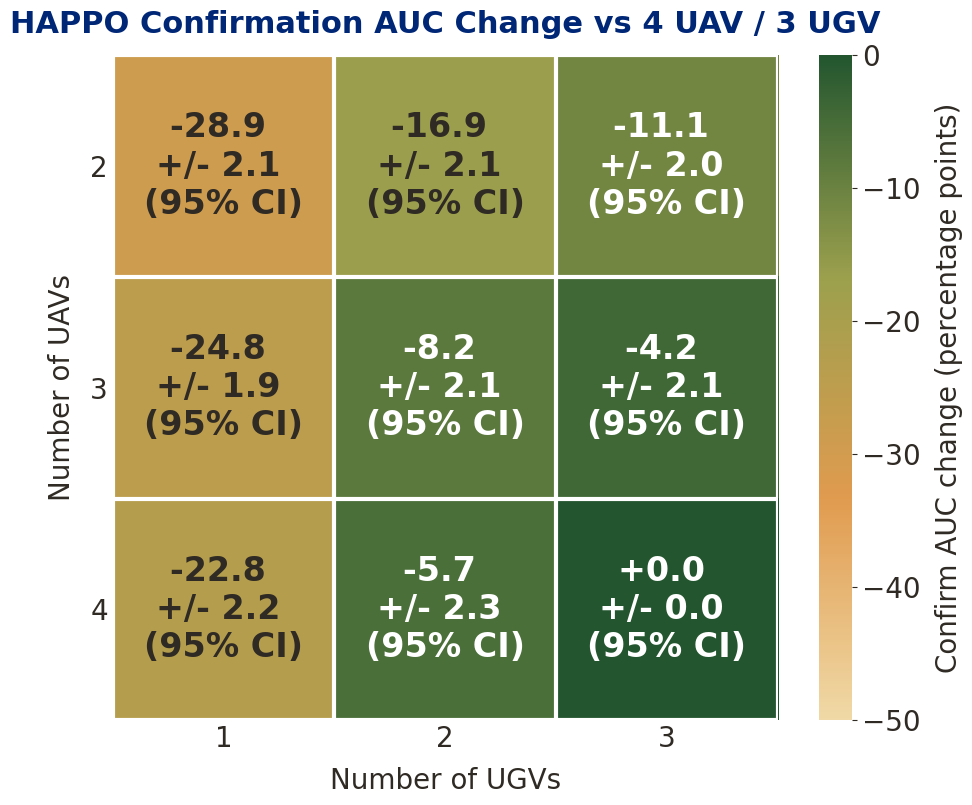

In [8]:
trained_combination = tuple(map(int, TRAINED_COMBINATION))
if trained_combination not in expected_combinations:
    raise ValueError(f'TRAINED_COMBINATION {trained_combination} is not in AGENT_COMBINATIONS')

trained_rows = metrics[
    (metrics['n_uavs'] == trained_combination[0])
    & (metrics['n_ugvs'] == trained_combination[1])
]
if len(trained_rows) != 1:
    raise ValueError(f'Expected exactly one result for TRAINED_COMBINATION={trained_combination}')
trained_row = trained_rows.iloc[0]
trained_by_seed = trained_row['confirm_auc_by_seed']


def _degradation_stats(row):
    combination = (int(row['n_uavs']), int(row['n_ugvs']))
    if combination == trained_combination:
        return 0.0, 0.0, len(trained_by_seed)

    current_by_seed = row['confirm_auc_by_seed']
    common_seeds = sorted(set(trained_by_seed) & set(current_by_seed))
    if common_seeds:
        paired = np.asarray([
            current_by_seed[seed] - trained_by_seed[seed]
            for seed in common_seeds
        ], dtype=float)
        sample_std = float(np.std(paired, ddof=1)) if len(paired) > 1 else float('nan')
        ci95 = 1.96 * sample_std / np.sqrt(len(paired)) if len(paired) > 1 else float('nan')
        return 100.0 * float(np.mean(paired)), 100.0 * ci95, len(common_seeds)

    # Compatibility fallback for older summaries without per-seed AUC values.
    mean = 100.0 * (row['confirm_auc_mean'] - trained_row['confirm_auc_mean'])
    trained_count = max(int(trained_row['episode_count']), 1)
    current_count = max(int(row['episode_count']), 1)
    ci95 = 1.96 * 100.0 * np.sqrt(
        trained_row['confirm_auc_std'] ** 2 / trained_count
        + row['confirm_auc_std'] ** 2 / current_count
    )
    return float(mean), float(ci95), 0


degradation_matrix = np.full_like(mean_matrix, np.nan)
degradation_ci95_matrix = np.full_like(mean_matrix, np.nan)
paired_seed_count_matrix = np.zeros_like(mean_matrix, dtype=int)
for _, row in metrics.iterrows():
    y = uav_index[int(row['n_uavs'])]
    x = ugv_index[int(row['n_ugvs'])]
    degradation, degradation_ci95, paired_count = _degradation_stats(row)
    degradation_matrix[y, x] = degradation
    degradation_ci95_matrix[y, x] = degradation_ci95
    paired_seed_count_matrix[y, x] = paired_count

fig, ax = plt.subplots(
    figsize=(2.25 * len(ugv_counts) + 3.0, 1.85 * len(uav_counts) + 2.6),
    facecolor=PAPER_BG,
)
ax.set_facecolor(PAPER_BG)
image = ax.imshow(
    np.ma.masked_invalid(degradation_matrix),
    cmap=cmap,
    vmin=-50.0,
    vmax=0.0,
    aspect='equal',
)

for y in range(len(uav_counts)):
    for x in range(len(ugv_counts)):
        mean = degradation_matrix[y, x]
        ci95 = degradation_ci95_matrix[y, x]
        if np.isfinite(mean):
            annotation = f'{mean:+.1f} \n+/- {ci95:.1f} \n(95% CI)' if np.isfinite(ci95) else f'{mean:+.1f} pp'
            color = 'white' if mean >= -15.0 else TEXT_DARK
        else:
            annotation = 'n/a'
            color = '#6f6758'
        ax.text(x, y, annotation, ha='center', va='center', color=color, fontsize=24, fontweight='bold')

ax.set_xticks(np.arange(len(ugv_counts)), labels=ugv_counts)
ax.set_yticks(np.arange(len(uav_counts)), labels=uav_counts)
ax.set_xlabel('Number of UGVs', fontsize=20, color=TEXT_DARK, labelpad=10)
ax.set_ylabel('Number of UAVs', fontsize=20, color=TEXT_DARK, labelpad=10)
ax.set_title(
    f'{APPROACH_LABEL} Confirmation AUC Change vs {trained_combination[0]} UAV / {trained_combination[1]} UGV',
    fontsize=22,
    fontweight='bold',
    color=TEXT_GREEN,
    pad=16,
)
ax.tick_params(axis='both', labelsize=20, colors=TEXT_DARK, length=0)
ax.set_xticks(np.arange(-0.5, len(ugv_counts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(uav_counts), 1), minor=True)
ax.grid(which='minor', color=PAPER_BG, linewidth=3)
ax.tick_params(which='minor', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.05)
colorbar.set_label('Confirm AUC change (percentage points)', fontsize=20, color=TEXT_DARK, labelpad=10)
colorbar.ax.tick_params(labelsize=20, colors=TEXT_DARK)
colorbar.outline.set_visible(False)
fig.tight_layout()
plt.savefig("../outputs/figures/agent_matrix.png")
plt.show()

